# Environmental Classification

## Imports

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    r2_score,
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline


import importlib
import green_dirty_month_data as _gdm




plt.style.use("dark_background")
sys.path.insert(0, str(Path.cwd().resolve()))
from shared.model_defs import GreenMonthTransformer
from shared.train_utils import run_epoch


## Data: CO₂ correlation and loaders

State-level annual CO₂ uses MSN **TETCE** from `research_data/08_seds_state_energy/complete_seds_all_energy_1960_2023.csv` (million metric tons). Monthly generation mix is loaded from `research_data/02_grid_operations/` (prefers `electric_power_operations_monthly_all_states.csv`, otherwise `electric_power_operations_2010_2024.csv`). ISO fuel-mix extracts live under `research_data/07_grid_stress/` (e.g. CAISO, ERCOT, PJM). **Green month** = renewable share ≥ state median (or global median if a state has very few months); model inputs do **not** include `ren_share`.

In [ ]:

# Cross-section (states): mean monthly fossil / renewable share vs annual TETCE (2023)
frame = build_labeled_frame(co2_year=2023)
by_state = frame.groupby("location", as_index=False).agg(
    mean_fos_share=("fos_share", "mean"),
    mean_ren_share=("ren_share", "mean"),
    tetce_mmt=("tetce_mmt", "first"),
)
r_fos = by_state["tetce_mmt"].corr(other=by_state["mean_fos_share"], method="pearson")
r_ren = by_state["tetce_mmt"].corr(other=by_state["mean_ren_share"], method="pearson")
print("Pearson r (states): TETCE vs mean fossil share  =", round(r_fos, 4))
print("Pearson r (states): TETCE vs mean renewable share =", round(r_ren, 4))

train_loader, test_loader, info = make_loaders(batch_size=32, test_size=0.3, random_state=42)
print(
    "n_states", info["n_states"],
    "| train batches", len(train_loader),
    "| test batches", len(test_loader),
)
print("Approx. class balance (full sample):", info["class_balance"])

## Greenest states by month

**Greenest** = highest **renewable share** (`REN / ALL` generation) among states in the monthly EIA extract. For each month, states are ranked and the top few are shown (not the ML label).

In [ ]:
importlib.reload(_gdm)
from green_dirty_month_data import monthly_top_green_states

TOP_N = 5
# Exclude from the top-by-ren_share slice (next-highest states fill in).
EXCLUDE_STATES = ("VT", "MT", "IA")
ranked = monthly_top_green_states(
    top_n=TOP_N, also_include=(), exclude_states=EXCLUDE_STATES
)
months_sorted = sorted(ranked["period"].unique())
n_m = len(months_sorted)
ncols = 4
nrows = int(np.ceil(n_m / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows), sharex=True)
axes = np.atleast_1d(axes).ravel()
for i, m in enumerate(months_sorted):
    ax = axes[i]
    sub = ranked[ranked["period"] == m].sort_values("rank")
    ax.barh(sub["state"], sub["ren_share"], color="seagreen", edgecolor="white", linewidth=0.5)
    ax.set_xlim(0, 1.2)
    ax.invert_yaxis()
    ax.set_title(pd.Timestamp(m).strftime("%b %Y"), fontsize=10)
    if i >= n_m - ncols:
        ax.set_xlabel("Renewable share (REN / ALL)")
    for _, r in sub.iterrows():
        ax.text(
            r["ren_share"] + 0.02,
            r["state"],
            f"{r['ren_share']:.0%}",
            va="center",
            fontsize=8,
        )
for j in range(len(months_sorted), len(axes)):
    axes[j].set_visible(False)
plt.suptitle(
    "Top 5 Green States",
    y=1.02,
    fontsize=11,
)
plt.tight_layout()
plt.show()

## Renewable mix: how states differ

Each bar is a state’s **average monthly renewable share** (REN / ALL, electric utility) minus the **national average** across all state–months. Positive values mean that state tends to run a greener mix than the U.S. average; negative values mean more fossil-heavy than average.

In [ ]:
import importlib


import numpy as np
import green_dirty_month_data as _gdm

importlib.reload(_gdm)

print("Using:", POWER_CSV.resolve())
p = load_power_state_month_table()
if len(p) == 0:
    raise RuntimeError("No rows after loading power table — check POWER_CSV path and fuel-type aggregation.")

national_mean = float(np.mean(p["ren_share"].to_numpy(dtype=np.float64)))
by_state = (
    p.groupby("location", as_index=False)["ren_share"]
    .mean()
    .rename(columns={"ren_share": "mean_ren_share"})
)
by_state["diff_pp"] = 100.0 * (by_state["mean_ren_share"] - national_mean)
by_state = by_state.sort_values("diff_pp", ascending=True)

fig_h = max(6.0, 0.22 * len(by_state))
fig, ax = plt.subplots(figsize=(10, fig_h))
y = by_state["location"].astype(str).to_numpy()
x = by_state["diff_pp"].to_numpy(dtype=np.float64)
bar_colors = np.where(x >= 0.0, "seagreen", "steelblue")
ax.barh(y, x, color=list(bar_colors), edgecolor="white", linewidth=0.4)
ax.axvline(0.0, color="black", linewidth=0.9)
ax.set_xlabel("Difference from national mean renewable share (percentage points)")
ax.set_title("State renewable mix vs national average")
plt.tight_layout()
plt.show()


## Renewable share vs retail electricity price

Each point is one of the **50 U.S. states** (D.C. and territories excluded): **x** = mean renewable share of utility-scale generation (REN / ALL) over all joined months, **y** = mean retail price (¢/kWh) over the same months. Price uses the **all-sectors** average; correlation is descriptive only (many confounders: policy, fuel costs, network costs).

States in chart: 50 | underlying months: 8885 | price sector: RES (residential) | retail_sales_price_revenue_monthly_all_states.csv
Pearson r (state means): 0.1312 | R² polynomial fit (deg 3 ): 0.1753


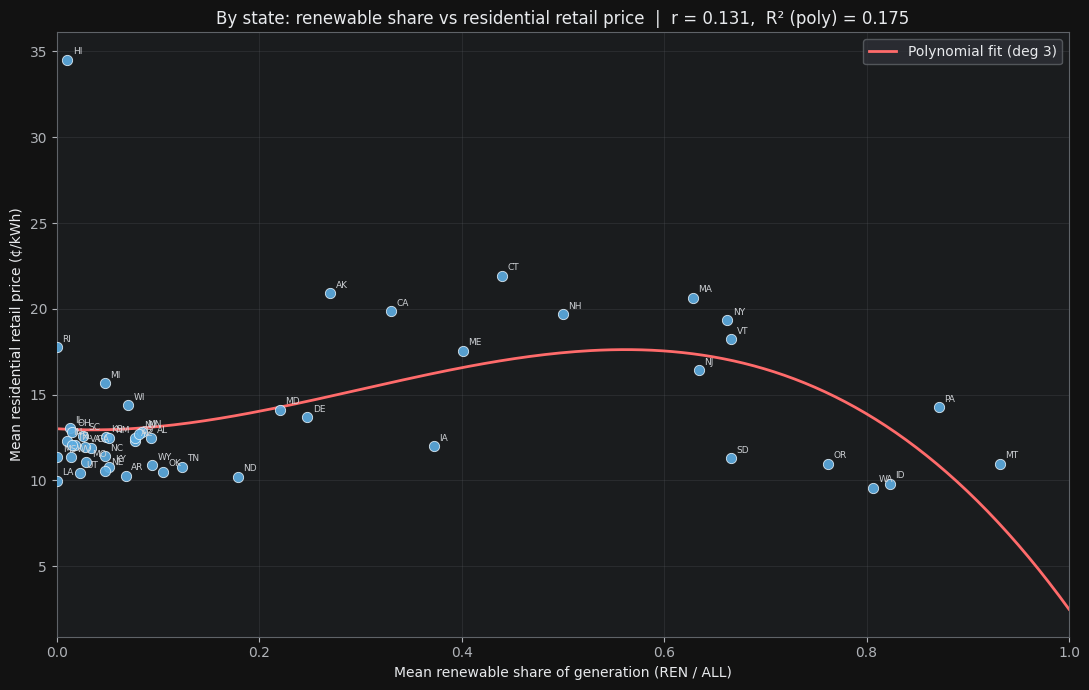

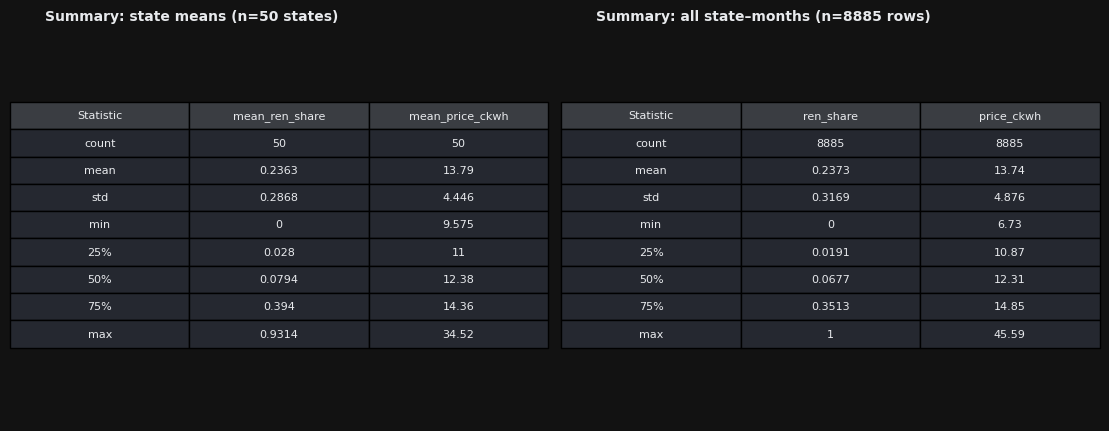

In [ ]:
_STATE50 = (
    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "FL", "GA",
    "HI", "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME", "MD",
    "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH", "NJ",
    "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI", "SC",
    "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY",
)
POLY_DEG = 3
# EIA retail price sector: RES = residential (see ``load_retail_price_state_month`` in ``green_dirty_month_data``)
PRICE_SECTOR = "RES"

combo = renewable_share_vs_retail_price(price_sector=PRICE_SECTOR)
by_state = combo.groupby("location", as_index=False).agg(
    mean_ren_share=("ren_share", "mean"),
    mean_price_ckwh=("price_ckwh", "mean"),
)
by_state = by_state[by_state["location"].isin(_STATE50)].sort_values("location")
r_price = float(
    by_state["mean_ren_share"].corr(
        other=by_state["mean_price_ckwh"], method="pearson"
    )
)
x = by_state["mean_ren_share"].to_numpy(dtype=np.float64)
y = by_state["mean_price_ckwh"].to_numpy(dtype=np.float64)
poly_coef = np.polyfit(x, y, POLY_DEG)
y_hat = np.poly1d(poly_coef)(x)
ss_res = float(np.sum((y - y_hat) ** 2))
ss_tot = float(np.sum((y - float(np.mean(y))) ** 2))
r2_poly = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")

print(
    "States in chart:",
    len(by_state),
    "| underlying months:",
    len(combo),
    "| price sector:",
    PRICE_SECTOR,
    "(residential)",
    "|",
    RETAIL_PRICE_CSV.name,
)
print("Pearson r (state means):", round(r_price, 4), "| R² polynomial fit (deg", POLY_DEG, "):", round(r2_poly, 4))

summary_by_state = (
    by_state[["mean_ren_share", "mean_price_ckwh"]]
    .describe()
    .round(4)
)
summary_panel = (
    combo[["ren_share", "price_ckwh"]]
    .describe()
    .round(4)
)


def _table_from_describe(ax, desc: pd.DataFrame, title: str) -> None:
    ax.axis("off")
    ax.set_facecolor("#1a1c1e")
    ax.set_title(title, fontsize=10, fontweight="bold", loc="left", pad=6, color="#e8eaed")
    rows = []
    for stat in desc.index:
        row = [stat]
        for c in desc.columns:
            v = desc.loc[stat, c]
            if stat == "count" and pd.notna(v):
                row.append(str(int(v)))
            elif pd.notna(v):
                row.append(f"{float(v):.4g}")
            else:
                row.append("")
        rows.append(row)
    col_labels = ["Statistic"] + list(desc.columns)
    tbl = ax.table(
        cellText=rows,
        colLabels=col_labels,
        loc="center",
        cellLoc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1.15, 1.35)
    for (row, col), cell in tbl.get_celld().items():
        cell.get_text().set_color("#e8eaed")
        if row == 0:
            cell.set_facecolor("#3a3d42")
        else:
            cell.set_facecolor("#252830")


# Dark theme for this cell only (does not change global matplotlib style)
with plt.style.context("dark_background"):
    fig_scatter, ax = plt.subplots(figsize=(11, 7))
    fig_scatter.patch.set_facecolor("#121212")
    ax.set_facecolor("#1a1c1e")
    ax.scatter(
        x,
        y,
        alpha=0.9,
        s=55,
        c="#5dade2",
        edgecolors="#e8f4fc",
        linewidth=0.6,
        zorder=3,
    )
    for st, xi, yi in zip(by_state["location"].astype(str), x, y):
        ax.annotate(
            st,
            (xi, yi),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=6.5,
            color="#d5d8dc",
            alpha=0.95,
            zorder=4,
        )
    grid = np.linspace(0.0, max(1.0, float(np.nanmax(x)) * 1.02), 200)
    ax.plot(
        grid,
        np.poly1d(poly_coef)(grid),
        color="#ff6b6b",
        linewidth=2.0,
        label=f"Polynomial fit (deg {POLY_DEG})",
        zorder=2,
    )
    ax.set_xlim(0.0, 1.0)
    ax.set_xlabel("Mean renewable share of generation (REN / ALL)", color="#e8eaed")
    ax.set_ylabel("Mean residential retail price (¢/kWh)", color="#e8eaed")
    ax.set_title(
        f"By state: renewable share vs residential retail price  |  r = {r_price:.3f},  R² (poly) = {r2_poly:.3f}",
        color="#e8eaed",
    )
    ax.tick_params(colors="#b0b3b8")
    ax.legend(loc="upper right", facecolor="#2d3036", edgecolor="#5f6368", labelcolor="#e8eaed")
    ax.grid(True, alpha=0.22, color="#5f6368")
    for spine in ax.spines.values():
        spine.set_color("#5f6368")

    plt.tight_layout()
    fig_scatter.savefig(
        "ren-share-price.png",
        dpi=300,
        bbox_inches="tight",
        facecolor=fig_scatter.get_facecolor(),
        edgecolor="none",
    )
    plt.show()

    fig_tables, (ax_tbl_state, ax_tbl_panel) = plt.subplots(
        1, 2, figsize=(11, 4.2), constrained_layout=True
    )
    fig_tables.patch.set_facecolor("#121212")
    _table_from_describe(
        ax_tbl_state,
        summary_by_state,
        f"Summary: state means (n={len(by_state)} states)",
    )
    _table_from_describe(
        ax_tbl_panel,
        summary_panel,
        f"Summary: all state–months (n={len(combo)} rows)",
    )
    plt.show()


## Predictive model: retail price vs renewable share (scenarios)

We fit **state fixed effects** (one coefficient per state, `OneHotEncoder(drop="first")`) plus a **degree-2 polynomial in renewable share**, with **Ridge** on the state–month panel. Train/test evaluation uses **`GroupShuffleSplit`** so **entire states** are held out together (no month from a test state leaking into training).

Scenario curves are drawn **per state** (thin gray) with the **mean across states** in crimson. The scenario table reports **mean / min / max** predicted price across the 50 states at each renewable-share level.

**Caveat:** This is a **statistical association** from history, not a causal forecast (policy, gas prices, and network costs also move prices).

In [ ]:

_STATE50 = (
    "AL", "AR", "AZ", "CA", "CO", "CT", "DE", "FL", "GA", "IA", "ID", "IL", "IN",
    "KS", "KY", "LA", "MA", "MD", "ME", "MI", "MN", "MO", "MS", "MT", "NC", "ND",
    "NE", "NH", "NJ", "NM", "NV", "NY", "OH", "OK", "OR", "PA", "RI", "SC", "SD",
    "TN", "TX", "UT", "VA", "VT", "WA", "WI", "WV", "WY",
)

combo = renewable_share_vs_retail_price(price_sector="ALL")
combo = combo[combo["location"].isin(_STATE50)].dropna(subset=["ren_share", "price_ckwh"]).copy()

X_df = combo[["location", "ren_share"]].copy()
y = combo["price_ckwh"].to_numpy()

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X_df, y, groups=combo["location"]))

RIDGE_ALPHA = 5.0
POLY_DEG = 2

price_model = Pipeline(
    [
        (
            "feats",
            ColumnTransformer(
                [
                    (
                        "state",
                        OneHotEncoder(
                            drop="first",
                            sparse_output=False,
                            categories=[sorted(_STATE50)],
                        ),
                        ["location"],
                    ),
                    (
                        "poly",
                        PolynomialFeatures(degree=POLY_DEG, include_bias=False),
                        ["ren_share"],
                    ),
                ]
            ),
        ),
        ("ridge", Ridge(alpha=RIDGE_ALPHA)),
    ]
)

price_model.fit(X_df.iloc[train_idx], y[train_idx])

y_tr_pred = price_model.predict(X_df.iloc[train_idx])
y_te_pred = price_model.predict(X_df.iloc[test_idx])
r2_train = r2_score(y[train_idx], y_tr_pred)
r2_test = r2_score(y[test_idx], y_te_pred)
mae_test = mean_absolute_error(y[test_idx], y_te_pred)

print(
    f"Panel: n={len(combo):,} state-months | state FE + poly deg={POLY_DEG} | Ridge α={RIDGE_ALPHA}"
)
print(
    f"Train R²={r2_train:.4f}  Test R²={r2_test:.4f}  Test MAE={mae_test:.4f} ¢/kWh "
    f"(grouped holdout: whole states in test)"
)
print(
    f"Observed ren_share range: [{combo['ren_share'].min():.3f}, {combo['ren_share'].max():.3f}]"
)

# Refit on full panel for scenario projection
price_model.fit(X_df, y)

share_lo, share_hi = float(combo["ren_share"].min()), float(combo["ren_share"].max())
grid = np.linspace(max(0.0, share_lo - 0.02), min(0.95, share_hi + 0.15), 120)

curves = []
for st in _STATE50:
    grid_df = pd.DataFrame({"location": st, "ren_share": grid})
    curves.append(price_model.predict(grid_df))
curve_mat = np.vstack(curves)
pred_mean = curve_mat.mean(axis=0)

scenario_levels = [0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75]
rows = []
for s in scenario_levels:
    sdf = pd.DataFrame({"location": list(_STATE50), "ren_share": s})
    p = price_model.predict(sdf)
    rows.append(
        {"ren_share": s, "pred_mean": p.mean(), "pred_min": p.min(), "pred_max": p.max()}
    )
scenario_tbl = pd.DataFrame(rows)
print("\nScenario table (¢/kWh): mean / min / max over 50 states at each renewable share:")
print(scenario_tbl.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

st_codes = pd.Categorical(combo["location"], categories=list(_STATE50)).codes
base = plt.cm.tab20.colors
base2 = plt.cm.tab20b.colors
base3 = plt.cm.Set3.colors
allc = np.vstack([base, base2, base3[:10]])
cmap50 = ListedColormap(allc)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    combo["ren_share"],
    combo["price_ckwh"],
    alpha=0.45,
    s=14,
    c=st_codes,
    cmap=cmap50,
    vmin=-0.5,
    vmax=49.5,
    label="State-month (by state color)",
)
for row in curve_mat:
    ax.plot(grid, row, color="gray", alpha=0.2, lw=0.9)
ax.plot(grid, pred_mean, color="crimson", lw=2.8, label="Mean predicted curve (across states)")
ax.axvline(share_hi, color="gray", ls="--", lw=1, label=f"Max observed share ({share_hi:.2f})")
ax.axvspan(share_lo, share_hi, alpha=0.08, color="green", label="Observed share range")
ax.set_xlabel("Renewable share of generation")
ax.set_ylabel("Retail price (¢/kWh)")
ax.set_title("Predicted retail price vs renewable share (state-grouped FE + scenarios)")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

## Projected renewable usage (top seven states)

**Table style** matches the commercial-price example: point forecast, **80% prediction interval** (lower / upper), **band width** (upper − lower), **national average** row, and **\*** on the two states with the **widest** bands among the seven.

**Method:** Ordinary least squares on **time** (years since the start of the EIA monthly extract) for each state’s monthly **renewable share of generation** (`REN / ALL`). The same linear trend is applied to **national** monthly shares (REN and ALL summed across states). **DC**, **Maine**, and **New Hampshire** are excluded from the state ranking. The table **replaces Montana with California** in the top-seven list (same projection model for CA). This is a simple extrapolation—not a policy or capacity forecast.

In [ ]:
top, national, meta = projected_renewable_usage_top_states(target="2028-12-01", top_n=7)

em = "\u2014"
title = "Table: Projected Renewable Generation Share — December 2028"
header = f"{'State':<26} {'Projected (%)':>14} {'Lower Bound':>14} {'Upper Bound':>14} {'Band Width':>12}"
rule = "-" * len(header)
rows_txt = [title, "", header, rule]
for _, r in top.iterrows():
    nm = r["state_name"] + ("*" if r["starred"] else "")
    rows_txt.append(
        f"{nm:<26} {r['projected_pct']:>14.2f} {r['lower_pct']:>14.2f} "
        f"{r['upper_pct']:>14.2f} {r['band_width']:>12.2f}"
    )
rows_txt.append(rule)
rows_txt.append(
    f"{'National avg':<26} {national['projected_pct']:>14.2f} {em:>14} {em:>14} {em:>12}"
)
rows_txt.extend(
    [
        "",
        "80% prediction interval.",
        (
            f"Linear trend fit on full {meta['data_start']}–{meta['data_end']} "
            "monthly EIA state electricity generation (renewable share of all fuels)."
        ),
        "* Widest uncertainty bands among these seven states.",
    ]
)
print("\n".join(rows_txt))

# Optional: publication-style grid (no vertical rules)
fig, ax = plt.subplots(figsize=(10.5, 3.8))
ax.axis("off")
cell_text = []
for _, r in top.iterrows():
    cell_text.append(
        [
            r["state_name"] + ("*" if r["starred"] else ""),
            f"{r['projected_pct']:.2f}",
            f"{r['lower_pct']:.2f}",
            f"{r['upper_pct']:.2f}",
            f"{r['band_width']:.2f}",
        ]
    )
cell_text.append(
    [
        "National avg",
        f"{national['projected_pct']:.2f}",
        em,
        em,
        em,
    ]
)
tbl = ax.table(
    cellText=cell_text,
    colLabels=["State", "Projected (%)", "Lower Bound", "Upper Bound", "Band Width"],
    loc="upper center",
    cellLoc="center",
)
tbl.scale(1.05, 1.9)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#f0f0f0")
    if row == len(cell_text):
        cell.set_text_props(weight="bold")
ax.set_title(title, fontsize=12, pad=12)
plt.tight_layout()
plt.show()

## Transformer classifier

Each sequence is **one prepended state token** (learned embedding → `d_model`) followed by the **six month feature tokens**. Self-attention runs over state + months; the classifier reads the **output at the state position** (CLS-style), so state identity is grouped in a single place instead of being repeated at every timestep.

In [ ]:
# Model imported from shared.model_defs in the imports cell.


## Training, metrics, and baselines

Train/test split is **30% of states** (not of rows): `GroupShuffleSplit` holds out **whole states** so no month from a test state appears in training. Baselines use the same split: majority class and logistic regression on the **last timestep** features.

**Note:** $R^2$ and **MAE** below use the **predicted probability of class “green”** vs. binary labels (0/1)—they summarize probability calibration, not a regression target. The next section plots metrics over epochs and test-set predictions.

In [ ]:
from green_dirty_month_data import make_loaders, tabular_last_timestep

_info = globals().get("info")
if (
    "train_loader" not in globals()
    or "test_loader" not in globals()
    or not isinstance(_info, dict)
    or "y_train" not in _info
    or "y_test" not in _info
    or "X_train" not in _info
    or "X_test" not in _info
):
    train_loader, test_loader, info = make_loaders(
        batch_size=32, test_size=0.3, random_state=42
    )
else:
    info = _info

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GreenMonthTransformer(
    n_features=info["n_features"],
    n_states=info["n_states"],
).to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

# Use shared training helper to avoid notebook drift.
def run_epoch_local(loader, train: bool):
    optimizer = opt if train else None
    return run_epoch(model, loader, loss_fn, optimizer, device)


## Plots: metrics over training, confusion matrices, predictions

Training curves use the **test** set each epoch (for monitoring). **R²** and **MAE** compare binary true labels to predicted **P(green)**. Confusion matrices use hard class predictions. The scatter plot shows **P(green)** vs. test sample index, colored by true class, with incorrect predictions circled.

In [ ]:
epochs = np.arange(1, n_epochs + 1)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
ax = axes[0, 0]
ax.plot(epochs, history["train_loss"], color="C0", label="train loss")
ax.set_xlabel("epoch")
ax.set_ylabel("cross-entropy loss")
ax.set_title("Training loss")
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[0, 1]
ax.plot(epochs, history["train_acc"], label="train acc", color="C1")
ax.plot(epochs, history["test_acc"], label="test acc", color="C2")
ax.set_xlabel("epoch")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1, 0]
ax.plot(epochs, history["test_err"], color="C3", label="test error (1 − acc)")
ax.set_xlabel("epoch")
ax.set_ylabel("error rate")
ax.set_title("Test classification error")
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1, 1]
ax.plot(epochs, history["test_r2"], label="test R2", color="C4")
ax.plot(epochs, history["test_mae"], label="test MAE", color="C5")
ax.set_xlabel("epoch")
ax.set_ylabel("score")
ax.set_title("R² and MAE on test")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# --- Confusion matrices (transformer vs logistic regression) ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels_disp = ["dirty (0)", "green (1)"]
cm_tf = confusion_matrix(y_te, p_te)
cm_lr = confusion_matrix(y_test, lr_p)
sns.heatmap(
    cm_tf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_disp,
    yticklabels=labels_disp,
    ax=axes[0],
)
axes[0].set_ylabel("True")
axes[0].set_xlabel("Predicted")
axes[0].set_title("Transformer")

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=labels_disp,
    yticklabels=labels_disp,
    ax=axes[1],
)
axes[1].set_ylabel("True")
axes[1].set_xlabel("Predicted")
axes[1].set_title("Logistic Regression")
plt.tight_layout()
plt.show()

# --- Predicted P(green): transformer vs test index ---
idx = np.arange(len(y_te))
wrong = p_te != y_te
fig, ax = plt.subplots(figsize=(11, 4))
sc = ax.scatter(
    idx,
    prob_te,
    c=y_te,
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    s=40,
    alpha=0.85,
    edgecolors="k",
    linewidths=0.2,
)
ax.scatter(
    idx[wrong],
    prob_te[wrong],
    s=120,
    facecolors="none",
    edgecolors="lime",
    linewidths=1.5,
    label="misclassified",
)
cb = plt.colorbar(sc, ax=ax)
cb.set_label("true label (0=dirty, 1=green)")
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.7, label="decision 0.5")
ax.set_xlabel("test sample i")
ax.set_ylabel("predicted P (green)")
ax.set_title("Transformer Predictions")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Side-by-side: true labels vs hard predictions ---
fig, ax = plt.subplots(figsize=(12, 3))
x = np.arange(len(y_te))
w = 0.35
ax.bar(x - w / 2, y_te, width=w, label="true", alpha=0.85, color="steelblue")
ax.bar(x + w / 2, p_te, width=w, label="predicted", alpha=0.85, color="coral")
ax.set_xlabel("test sample index")
ax.set_ylabel("class (0 or 1)")
ax.set_title("Transformer: true vs predicted class (test)")
ax.legend()
ax.set_ylim(-0.15, 1.25)
plt.tight_layout()
plt.show()

# --- Logistic regression: P(green) vs index ---
wrong_lr = lr_p != y_test
fig, ax = plt.subplots(figsize=(11, 4))
sc2 = ax.scatter(
    np.arange(len(y_test)),
    lr_prob,
    c=y_test,
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    s=40,
    alpha=0.85,
    edgecolors="k",
    linewidths=0.2,
)
ax.scatter(
    np.arange(len(y_test))[wrong_lr],
    lr_prob[wrong_lr],
    s=120,
    facecolors="none",
    edgecolors="lime",
    linewidths=1.5,
    label="misclassified",
)
plt.colorbar(sc2, ax=ax).set_label("true label")
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.7)
ax.set_xlabel("test sample index")
ax.set_ylabel("predicted P (green)")
ax.set_title("Logistic regression Predictions")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
cats = ["Train", "Test"]
accs = [lr_train_acc, lr_test_acc]
colors = ["steelblue", "darkorange"]
bars = ax.bar(cats, accs, color=colors, edgecolor="k", linewidth=0.8)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.set_title("Logistic regression accuracy")
for b, v in zip(bars, accs):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.02, f"{v:.3f}", ha="center", va="bottom", fontsize=11)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()